In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
def read_h5_file(output_file):
    simulation_data = {}
    with h5py.File(output_file, 'r') as f:
        # Read global attributes safely
        attributes = {
            "total_chicken_population": f.attrs.get("total_chicken_population", None),
            "duck_symptomatic_probability": f.attrs.get("duck_symptomatic_probability", None),
        }

        # Iterate over simulation groups
        for sim_name in f:
            sim_group = f[sim_name]
            
            if "time" in sim_group and "state" in sim_group:
                t = sim_group["time"][:]
                y = sim_group["state"][:]
                simulation_data[sim_name] = {"time": t, "state": y}
            else:
                print(f"Warning: Missing 'time' or 'state' in {sim_name}")

    return simulation_data, attributes

In [3]:
def if_outbreak(t, y, outbreak_threshold=5):
    """Determine if an outbreak occurs based on the final time step."""
    return np.sum(y[-1, :, :, 5:]) >= outbreak_threshold

In [4]:
def passive_surveillance(t, y, alert_threshold=2):
    """Find the first time passive surveillance detects an outbreak."""
    threshold_reached = np.where(np.sum(y[:, :, :, 6], axis=(1, 2)) >= alert_threshold)[0]

    if len(threshold_reached) > 0:
        return t[threshold_reached[0]], np.trapz(np.sum(y[:threshold_reached[0]+1, :, :, 3:5], axis=(1, 2, 3)), t[:threshold_reached[0]+1])
    else:
        return np.nan, np.nan

In [5]:
def create_df(simulation_data):
    """Create a DataFrame summarizing outbreak and detection times and store associated states."""
    results = []

    for sim_name, data in simulation_data.items():
        outbreak = if_outbreak(data["time"], data["state"])
        
        pas_2, y2 = passive_surveillance(data["time"], data["state"], alert_threshold=2)
        pas_4, y4 = passive_surveillance(data["time"], data["state"], alert_threshold=4)
        pas_6, y6 = passive_surveillance(data["time"], data["state"], alert_threshold=6)
        
        final_deaths = np.sum(data["state"][-1, :, :, 6:])
        final_removed = np.sum(data["state"][-1, :, :, 5:])

        results.append([sim_name, outbreak, pas_2, y2, pas_4, y4, pas_6, y6, final_deaths, final_removed])

    # Create DataFrame
    df = pd.DataFrame(results, columns=[
        "simulation", "outbreak", 
        "passive_surveillance_threshold_2", "y2_state", 
        "passive_surveillance_threshold_4", "y4_state", 
        "passive_surveillance_threshold_6", "y6_state",
        "final_deaths", "final_removed"
    ])

    # Convert detection time columns to numeric
    for col in ["passive_surveillance_threshold_2", "passive_surveillance_threshold_4", "passive_surveillance_threshold_6"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")  # Ensures NaNs are properly handled

    return df

In [6]:
totpop = range(20, 201, 20)  # Example: total population from 20 to 200 in steps of 20
chicken_popul_proportion = [0, 0.25, 0.5, 0.75, 1.0]  # Proportion of chickens in the total population

file_template = "Raw_simu_files/chicken_{}_symprob_0.2_totpop_{}_rand_0_index_0_freq_0.h5"

def process_files(chicken_prop, totpop):
    all_results = []

    for chicken in chicken_prop:
        for t in totpop:
            if chicken > t:
                continue
        output_file = file_template.format(int(chicken * t), t)
        simulation_data, attributes = read_h5_file(output_file)  # Read H5 file

        df = create_df(simulation_data)  # Create DataFrame
        df["chicken_prop"] = chicken  # Add chicken level info
        df["total_population"] = t  # Add total population info

        all_results.append(df)  # Append to results list

    # Combine all into a single DataFrame
    combined_df = pd.concat(all_results, ignore_index=True)
    return combined_df

# Run the function
df_all = process_files(chicken_popul_proportion, totpop)


In [7]:
df_all.head()

,simulation,outbreak,passive_surveillance_threshold_2,y2_state,passive_surveillance_threshold_4,y4_state,passive_surveillance_threshold_6,y6_state,final_deaths,final_removed,chicken_prop,total_population
0,simulation_1,True,3.227981,75.847095,3.540621,109.474338,4.219982,200.946019,30.0,200.0,0.0,200
1,simulation_10,True,3.330888,111.424255,4.141282,221.841135,4.840094,332.387997,25.0,200.0,0.0,200
2,simulation_100,True,5.607466,57.411142,6.304896,126.224018,6.879637,205.556015,38.0,200.0,0.0,200
3,simulation_1000,True,2.525449,28.137184,3.615614,118.784314,3.772260,139.235063,34.0,200.0,0.0,200
4,simulation_1001,True,4.453435,57.624317,4.808406,86.207788,5.139018,122.621528,33.0,200.0,0.0,200


In [8]:
# Function to compute detection time
def compute_detection_time(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            detection_times = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    state = f[sim_name]["state"][:]  # shape: (T, x, y, C)
                    times = f[sim_name]["time"][:]
                    deaths = np.sum(state[:, :, :, 6], axis=(1, 2))  # deaths over time
                    detected = np.where(deaths >= threshold)[0]
                    if detected.size > 0:
                        detection_times.append(times[detected[0]])
            return np.mean(detection_times) if detection_times else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan

# Compute burden function
def compute_burden(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            burdens = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    y = f[sim_name]["state"][:]
                    t = f[sim_name]["time"][:]
                    cum_deaths = np.sum(y[:, :, :, 6], axis=(1, 2))
                    detect_idx = np.where(cum_deaths >= threshold)[0]
                    if detect_idx.size > 0:
                        stop = detect_idx[0] + 1
                        infectious = np.sum(y[:stop, :, :, 3:5], axis=(1, 2, 3))  # symptomatic + asymptomatic
                        burden = np.trapz(infectious, t[:stop])
                        burdens.append(burden)
            return np.mean(burdens) if burdens else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan

    
data_points_detection_time = np.zeros((len(chicken_popul_proportion), len(totpop)))
data_points_burden = np.zeros((len(chicken_popul_proportion), len(totpop)))



for i, chicken in enumerate(chicken_popul_proportion):
    for j, t in enumerate(totpop):
        chicken_pop = int(chicken * t)
        if chicken > t:
            continue
        output_file = file_template.format(chicken_pop, t)
        mean_detection_time = compute_detection_time(output_file, threshold=2)
        mean_burden = compute_burden(output_file, threshold=2)
        data_points_burden[i, j] = mean_burden
        data_points_detection_time[i, j] = mean_detection_time
    


        


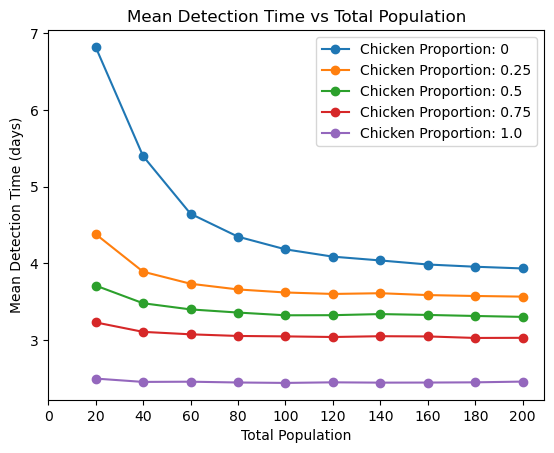

In [9]:
for chicken_prop in range(len(chicken_popul_proportion)):
    plt.plot(totpop, data_points_detection_time[chicken_prop, :], marker='o', label=f'Chicken Proportion: {chicken_popul_proportion[chicken_prop]}')
    plt.legend()

plt.xlabel('Total Population')
plt.ylabel('Mean Detection Time (days)')
plt.title('Mean Detection Time vs Total Population')
plt.xticks(range(0, 201, 20))
plt.show()



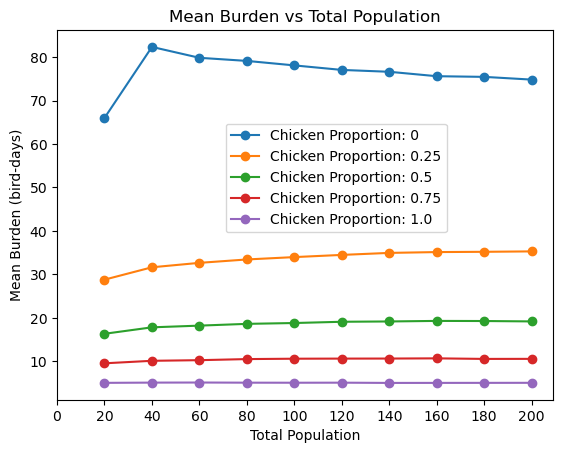

In [14]:
for chicken_prop in range(len(chicken_popul_proportion)):
    plt.plot(totpop, data_points_burden[chicken_prop, :], marker='o', label=f'Chicken Proportion: {chicken_popul_proportion[chicken_prop]}')
plt.legend(loc='right', bbox_to_anchor=(0.8, 0.6))

plt.xlabel('Total Population')
plt.ylabel('Mean Burden (bird-days)')
plt.title('Mean Burden vs Total Population')
plt.xticks(range(0, 201, 20))
plt.show()

